In [3]:
# ── Setup Image Directory (Kaggle Version) ───────────────────────────
import os
IMAGE_DIR = "/kaggle/input/datasets/flopadopa/images/images"

## Data exploration

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain

# ── Load metadata ──────────────────────────────────────────────
with open("/kaggle/input/datasets/flopadopa/metadata/minifigs.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(df.shape)
df.head(3)

(17362, 15)


,id,name,link,year,img_url,minifig_number,category,subcategory,year_released,set_id,current_value_new,current_value_used,character_name,img_local_path,themes
0,1,"LEGOLAND - Black Torso, Black Legs, Black Cowb...",/minifigs/old040/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old04...,OLD040,LEGOLAND,General,1975,1 set,~€5.28,~€1.85,None,images/OLD040.jpg,[LEGOLAND]
1,2,"LEGOLAND - Black Torso, Black Legs, Black Hat",/minifigs/old011/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old01...,OLD011,LEGOLAND,General,1975,7 sets,Not known,~€1.53,None,images/OLD011.jpg,"[Basic, LEGOLAND, Universal Building Set]"
2,3,"LEGOLAND - Black Torso, Black Legs, White Hat",/minifigs/old009/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old00...,OLD009,LEGOLAND,General,1975,2 sets,~€3.37,~€1.42,None,images/OLD009.jpg,[LEGOLAND]


In [5]:
# ── Inspect themes column ──────────────────────────────────────
print(df["themes"].head(10))
print("\nRows with empty themes:", df["themes"].apply(lambda x: len(x) == 0).sum())

0                                   [LEGOLAND]
1    [Basic, LEGOLAND, Universal Building Set]
2                                   [LEGOLAND]
3                                   [LEGOLAND]
4                                   [LEGOLAND]
5                                   [LEGOLAND]
6                                   [LEGOLAND]
7    [Basic, LEGOLAND, Universal Building Set]
8                                   [LEGOLAND]
9                                     [Trains]
Name: themes, dtype: object

Rows with empty themes: 0


In [6]:
# ── Count how often each theme appears ────────────────────────
all_themes = list(chain.from_iterable(df["themes"]))
theme_counts = Counter(all_themes)

print(f"Total unique themes: {len(theme_counts)}")
print("\nTop 20 themes:")
for theme, count in theme_counts.most_common(20):
    print(f"  {theme:<40} {count}")

Total unique themes: 144

Top 20 themes:
  City                                     2001
  Star Wars                                1477
  Ninjago                                  929
  Friends                                  877
  Duplo                                    836
  Collectable Minifigures                  782
  Marvel Super Heroes                      703
  Town                                     700
  Harry Potter                             637
  Castle                                   459
  Education                                454
  Disney                                   387
  DC Comics Super Heroes                   308
  Icons                                    294
  Ideas                                    279
  BrickLink                                270
  Promotional                              258
  Dacta                                    253
  Minecraft                                251
  Sports                                   234


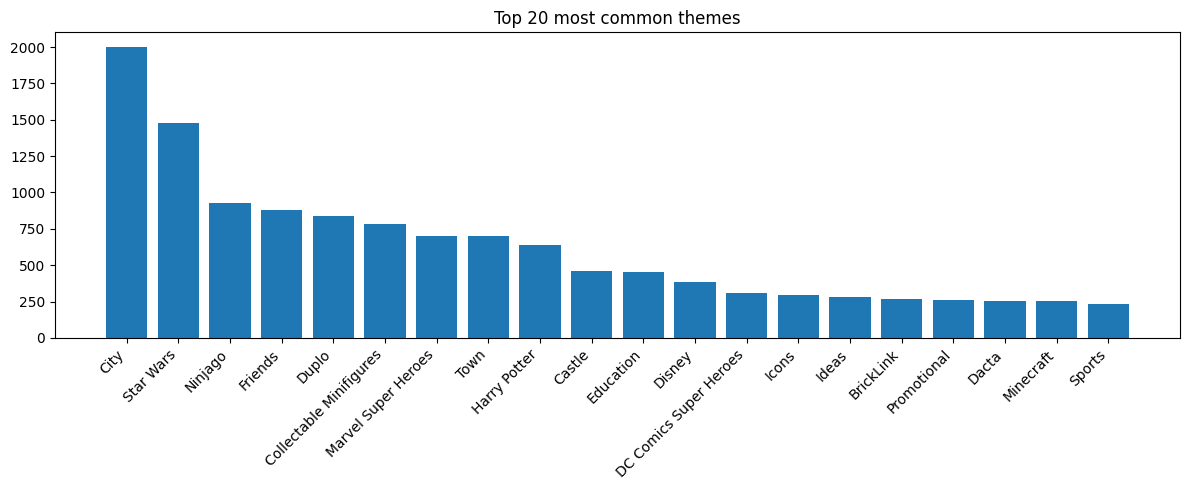

In [7]:
# ── Plot top 20 themes ─────────────────────────────────────────
top_themes = theme_counts.most_common(20)
labels, counts = zip(*top_themes)

plt.figure(figsize=(12, 5))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 most common themes")
plt.tight_layout()
plt.show()

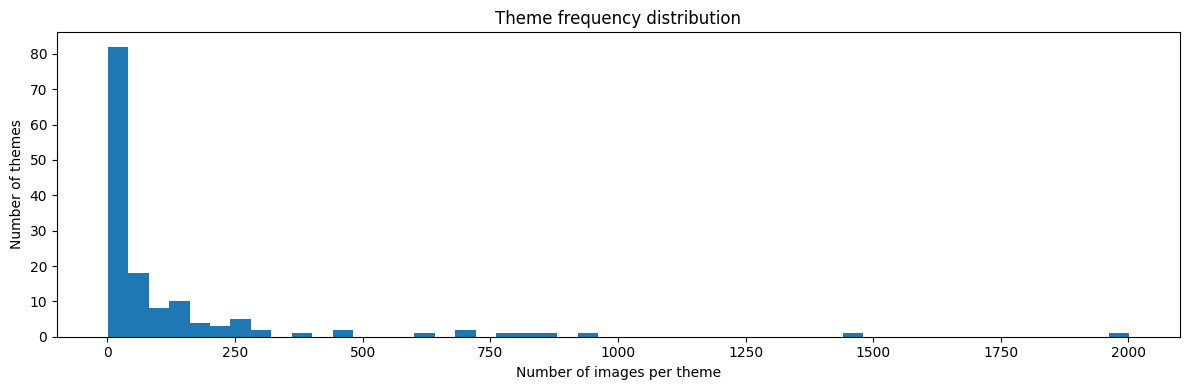

Themes with less than 10 examples: 25 / 144
Themes with less than 25 examples: 57 / 144
Themes with less than 50 examples: 89 / 144
Themes with less than 100 examples: 105 / 144


In [8]:
# ── Distribution of theme frequencies ─────────────────────────
counts_values = list(theme_counts.values())

plt.figure(figsize=(12, 4))
plt.hist(counts_values, bins=50)
plt.xlabel("Number of images per theme")
plt.ylabel("Number of themes")
plt.title("Theme frequency distribution")
plt.tight_layout()
plt.show()

# ── How many themes have less than X examples ──────────────────
for threshold in [10, 25, 50, 100]:
    rare = sum(1 for c in counts_values if c < threshold)
    print(f"Themes with less than {threshold} examples: {rare} / {len(theme_counts)}")

In [9]:
# ── Select themes with at least 50 images ────────────────────────────────────────
THRESHOLD = 50
selected_themes = [theme for theme, count in theme_counts.items() if count>= THRESHOLD]
print(f"{len(selected_themes)} themes with>={THRESHOLD} images.")
print("Selected themes:", selected_themes)

# ── How many images have at least one of the top-k themes ──────
df["top_themes"] = df["themes"].apply(
    lambda x: [t for t in x if t in selected_themes]
)
covered = df["top_themes"].apply(lambda x: len(x) > 0).sum()
print(f"\nImages with at least one theme (min {THRESHOLD}): {covered} / {len(df)} ({100*covered/len(df):.1f}%)")

# ── Average number of labels per image (among covered ones) ────
avg_labels = df[df["top_themes"].apply(len) > 0]["top_themes"].apply(len).mean()
print(f"Average themes per image (covered): {avg_labels:.2f}")

55 themes with>=50 images.
Selected themes: ['Basic', 'Trains', 'Dacta', 'Duplo', 'Castle', 'Space', 'Town', 'Fabuland', 'Sports', 'Gear', 'Education', 'Pirates', 'Belville', 'Adventurers', 'Harry Potter', 'The Hobbit', 'Miscellaneous', 'Promotional', 'Explore', 'Racers', 'Star Wars', 'Creator', 'Advanced models', 'City', 'Juniors', 'Indiana Jones', 'Games', 'Collectable Minifigures', 'Seasonal', 'Cars', 'DC Comics Super Heroes', 'Ninjago', 'The LEGO Movie', 'Marvel Super Heroes', 'Friends', 'Dimensions', 'Ideas', 'Creator Expert', 'Teenage Mutant Ninja Turtles', 'Legends of Chima', 'Minecraft', 'BrickLink', 'Hidden Side', 'Monkie Kid', 'The LEGO Ninjago Movie', 'Disney', 'The LEGO Movie 2', 'The LEGO Batman Movie', 'Jurassic World', 'Elves', 'Icons', 'Speed Champions', 'Nexo Knights', 'Super Mario', 'Dreamzzz']

Images with at least one theme (min 50): 15861 / 17362 (91.4%)
Average themes per image (covered): 1.04


In [10]:
import os

# ── Keep only images that have at least one selected theme ───────
df_filtered = df[df["top_themes"].apply(len) > 0].copy()
df_filtered = df_filtered.dropna(subset=["img_local_path"])
df_filtered = df_filtered.reset_index(drop=True)
print(f"Dataset size after filtering: {len(df_filtered)}")

# ── Check how many images actually exist on disk ───────────────
df_filtered["img_exists"] = df_filtered["img_local_path"].apply(
    lambda x: os.path.exists(os.path.join(IMAGE_DIR, os.path.basename(x)))
)

print(f"Images found on disk: {df_filtered['img_exists'].sum()} / {len(df_filtered)}")

# ── Keep only rows where image exists ─────────────────────────
df_filtered = df_filtered[df_filtered["img_exists"]].reset_index(drop=True)
print(f"Final dataset size: {len(df_filtered)}")

Dataset size after filtering: 15860
Images found on disk: 15860 / 15860
Final dataset size: 15860


## Data split

In [11]:
# ── Install if needed ──────────────────────────────────────────
import numpy as np
from sklearn.model_selection import train_test_split

# ── Build the binary label matrix ─────────────────────────────
# Each row is an image, each column is a theme (1 if present, 0 if not)
TOP_K = len(selected_themes)
label_matrix = np.zeros((len(df_filtered), TOP_K), dtype=np.float32)

for i, themes in enumerate(df_filtered["top_themes"]):
    for theme in themes:
        j = selected_themes.index(theme)
        label_matrix[i, j] = 1.0

print("Label matrix shape:", label_matrix.shape)
print("Example (first row):", label_matrix[0], "->", df_filtered["top_themes"].iloc[0])

Label matrix shape: (15860, 55)
Example (first row): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0.] -> ['Basic']


In [12]:
from skmultilearn.model_selection import iterative_train_test_split

# ── First split: separate test set (15%) ──────────────────────
indices = np.arange(len(df_filtered)).reshape(-1, 1)

idx_trainval, labels_trainval, idx_test, labels_test = iterative_train_test_split(
    indices, label_matrix, test_size=0.15
)

# ── Second split: separate val from train (15% of total ≈ 17.6% of trainval) ──
idx_train, labels_train, idx_val, labels_val = iterative_train_test_split(
    idx_trainval, labels_trainval, test_size=0.176
)

idx_train = idx_train.flatten()
idx_val   = idx_val.flatten()
idx_test  = idx_test.flatten()

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Train: 11096 | Val: 2374 | Test: 2390


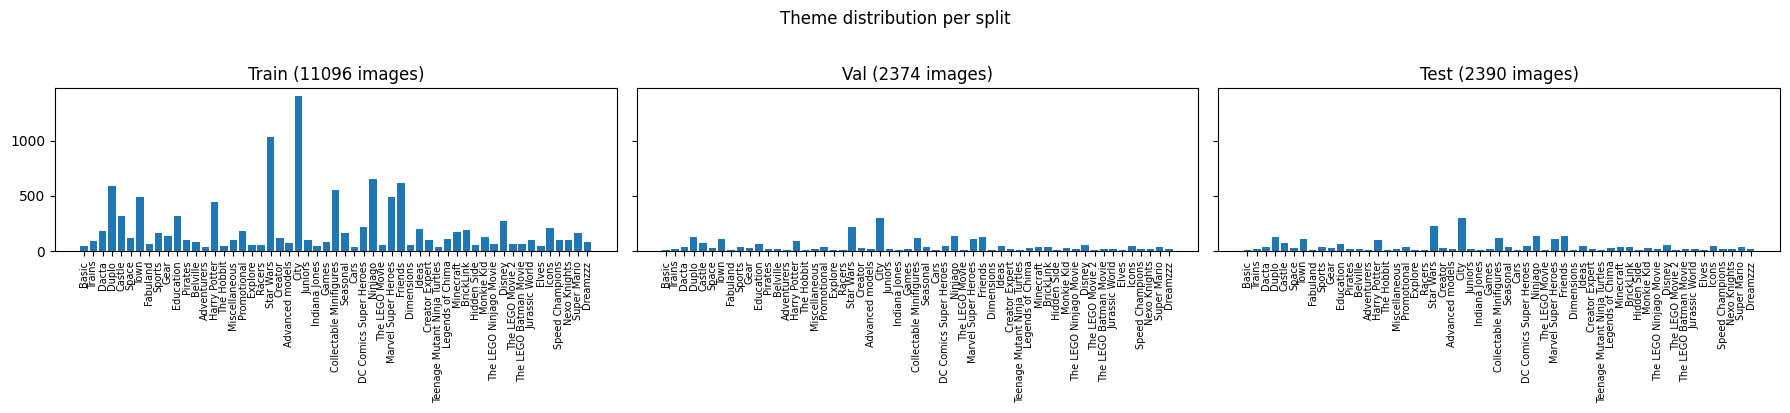

In [13]:
# ── Verify theme distribution is similar across splits ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, idx, labels) in zip(axes, [
    ("Train", idx_train, labels_train),
    ("Val",   idx_val,   labels_val),
    ("Test",  idx_test,  labels_test),
]):
    theme_sums = labels.sum(axis=0)
    ax.bar(range(TOP_K), theme_sums)
    ax.set_xticks(range(TOP_K))
    ax.set_xticklabels(selected_themes, rotation=90, fontsize=7)
    ax.set_title(f"{name} ({len(idx)} images)")

plt.suptitle("Theme distribution per split", y=1.02)
plt.tight_layout()
plt.show()

## Dataset y dataLoader

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ── Transforms for training (with augmentation) ────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    # ImageNet mean and std since SqueezeNet was pretrained on it
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Transforms for val and test (no augmentation, just normalize) ──
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [15]:
class LegoDataset(Dataset):
    def __init__(self, df, indices, labels, image_dir, transform=None):
        self.df        = df.iloc[indices].reset_index(drop=True)
        self.labels    = labels          # binary matrix (N x TOP_K)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Build the full path to the image
        img_name = os.path.basename(self.df.iloc[idx]["img_local_path"])
        img_path = os.path.join(self.image_dir, img_name)

        # Open image and convert to RGB (some PNGs have 4 channels)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Label is a float tensor of shape (TOP_K,)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return image, label

In [16]:
import os

# ── Create datasets ────────────────────────────────────────────
train_dataset = LegoDataset(df_filtered, idx_train, labels_train, IMAGE_DIR, train_transforms)
val_dataset   = LegoDataset(df_filtered, idx_val,   labels_val,   IMAGE_DIR, eval_transforms)
test_dataset  = LegoDataset(df_filtered, idx_test,  labels_test,  IMAGE_DIR, eval_transforms)

# ── Create dataloaders ─────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2774
Val batches:   594
Test batches:  598


Image batch shape: torch.Size([4, 3, 224, 224])
Label batch shape: torch.Size([4, 55])


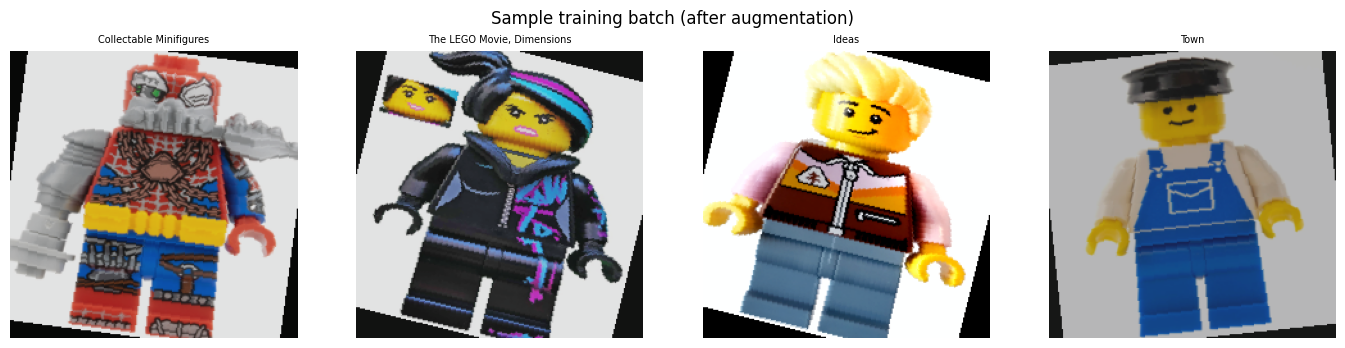

In [17]:
import matplotlib.pyplot as plt

# ── Sanity check: visualize a batch ───────────────────────────
images, labels_batch = next(iter(train_loader))
print("Image batch shape:", images.shape)   # should be (32, 3, 224, 224)
print("Label batch shape:", labels_batch.shape)  # should be (32, 20)

# Show a few images with their themes
# Adjusted subplot to match batch size (which is 4)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for i, ax in enumerate(axes.flat):
    if i >= images.shape[0]: # Ensure we don't go out of bounds if batch size is smaller than expected
        break
    img = images[i].permute(1, 2, 0).numpy()
    # Undo normalization for display
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)
    ax.imshow(img)
    themes_present = [selected_themes[j] for j in range(TOP_K) if labels_batch[i][j] == 1]
    ax.set_title(", ".join(themes_present), fontsize=7)
    ax.axis("off")

plt.suptitle("Sample training batch (after augmentation)")
plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn as nn
from torchvision import models

# ── Load pretrained SqueezeNet ─────────────────────────────────
model = models.squeezenet1_1(weights="IMAGENET1K_V1")

# ── Replace the classifier for multilabel (TOP_K outputs) ──────
# Original final conv: 512 -> 1000 classes
# We replace it with:  512 -> TOP_K classes
model.classifier[1] = nn.Conv2d(512, TOP_K, kernel_size=(1, 1), stride=(1, 1))
model.num_classes = TOP_K

# ── Check if GPU is available ──────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)
print(model)

Using device: cuda
SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )

In [19]:
# ── Fix classifier: remove ReLU after final conv ──────────────
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Conv2d(512, TOP_K, kernel_size=(1, 1), stride=(1, 1)),
    nn.AdaptiveAvgPool2d(output_size=(1, 1))
)
model = model.to(device)

# Verify the classifier looks correct now
print(model.classifier)


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Conv2d(512, 55, kernel_size=(1, 1), stride=(1, 1))
  (2): AdaptiveAvgPool2d(output_size=(1, 1))
)


## Training

In [20]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# ── Loss function for multilabel classification ────────────────
# BCEWithLogitsLoss = sigmoid + binary cross entropy, numerically stable
criterion = nn.BCEWithLogitsLoss()

# ── Optimizer: Adam with a small learning rate for fine-tuning ─
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ── Scheduler: reduce LR by half every 5 epochs ───────────────
# This helps the model converge more precisely over time
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

In [21]:
import torch
from torch.amp import GradScaler, autocast # Updated import for mixed precision

def report_gpu_memory(step_name):
    if torch.cuda.is_available():
        allocated_bytes = torch.cuda.memory_allocated()
        cached_bytes = torch.cuda.memory_reserved()
        print(f"[{step_name}] GPU Memory: Allocated: {allocated_bytes / (1024**2):.2f} MB, Cached: {cached_bytes / (1024**2):.2f} MB")
    else:
        print(f"[{step_name}] GPU not available. Cannot report memory.")

def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0

    # Clear GPU cache at the beginning of each epoch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        report_gpu_memory("Start of Epoch - Cache Cleared")

    for i, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast(device_type='cuda'): # Updated for mixed precision
            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # Optional: Report memory every N iterations (e.g., 100 batches)
        #if i % 100 == 0:
        #    report_gpu_memory(f"Batch {i}/{len(loader)}")

    #report_gpu_memory("End of Epoch")
    return running_loss / len(loader)

In [22]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():              # no gradients needed for evaluation
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Apply sigmoid to get probabilities, then threshold at 0.5
            preds = torch.sigmoid(outputs) > 0.5
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return running_loss / len(loader), all_preds, all_labels

In [26]:
from sklearn.metrics import f1_score
import torch
from torch.amp import GradScaler # Updated import for GradScaler

# ── Training loop ──────────────────────────────────────────────
NUM_EPOCHS = 10
best_val_f1 = 0.0

scaler = GradScaler(device='cuda') # Updated initialization for GradScaler

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    # F1 score macro: treats all themes equally regardless of frequency
    val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1: {val_f1:.4f}")

    # Save best model based on F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")
        print("  --> Best model saved")

[Start of Epoch - Cache Cleared] GPU Memory: Allocated: 45.13 MB, Cached: 54.00 MB
Epoch 01/10 | Train Loss: 0.0524 | Val Loss: 0.0507 | Val F1: 0.1858
  --> Best model saved
[Start of Epoch - Cache Cleared] GPU Memory: Allocated: 48.00 MB, Cached: 66.00 MB
Epoch 02/10 | Train Loss: 0.0485 | Val Loss: 0.0504 | Val F1: 0.1992
  --> Best model saved
[Start of Epoch - Cache Cleared] GPU Memory: Allocated: 48.00 MB, Cached: 66.00 MB
Epoch 03/10 | Train Loss: 0.0462 | Val Loss: 0.0520 | Val F1: 0.2170
  --> Best model saved
[Start of Epoch - Cache Cleared] GPU Memory: Allocated: 48.00 MB, Cached: 66.00 MB
Epoch 04/10 | Train Loss: 0.0444 | Val Loss: 0.0490 | Val F1: 0.2154
[Start of Epoch - Cache Cleared] GPU Memory: Allocated: 48.00 MB, Cached: 66.00 MB
Epoch 05/10 | Train Loss: 0.0398 | Val Loss: 0.0452 | Val F1: 0.2996
  --> Best model saved
[Start of Epoch - Cache Cleared] GPU Memory: Allocated: 48.00 MB, Cached: 66.00 MB
Epoch 06/10 | Train Loss: 0.0389 | Val Loss: 0.0434 | Val F1: 0.3

## Visualization epoch results

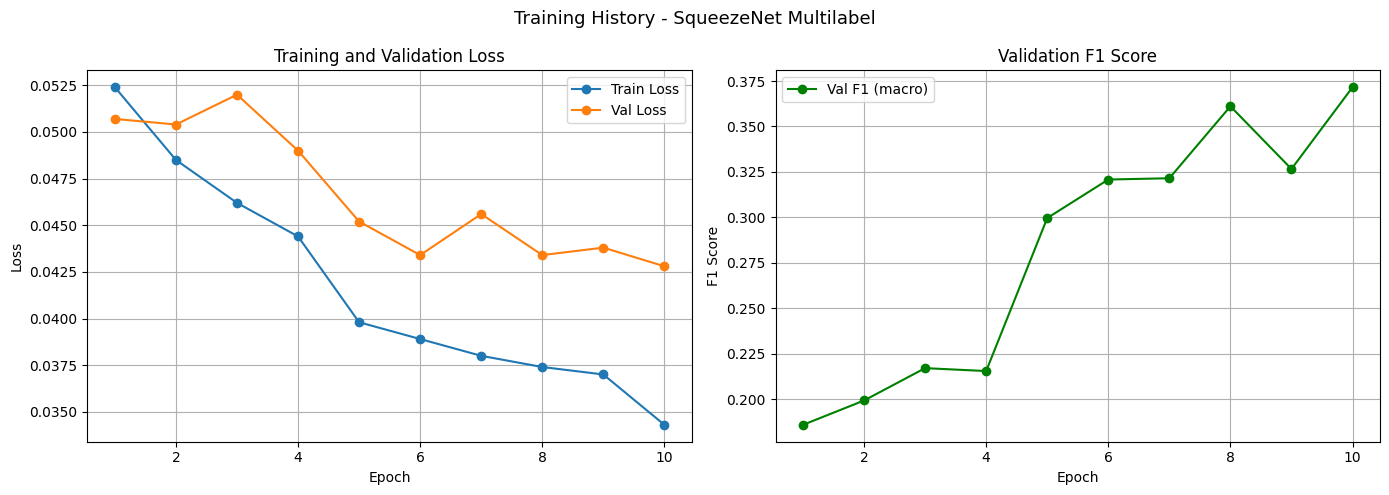

In [27]:
# ── Training history (logged manually from output) ────────────
history = {
    "train_loss": [0.0524, 0.0485, 0.0462, 0.0444, 0.0398, 0.0389, 0.0380, 0.0374, 0.0370, 0.0343],
    "val_loss":   [0.0507, 0.0504, 0.0520, 0.0490, 0.0452, 0.0434, 0.0456, 0.0434, 0.0438, 0.0428],
    "val_f1":     [0.1858, 0.1992, 0.2170, 0.2154, 0.2996, 0.3208, 0.3215, 0.3611, 0.3266, 0.3716]
}
epochs = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True)

# F1 curve
ax2.plot(epochs, history["val_f1"], label="Val F1 (macro)", marker="o", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Score")
ax2.set_title("Validation F1 Score")
ax2.legend()
ax2.grid(True)

plt.suptitle("Training History - SqueezeNet Multilabel", fontsize=13)
plt.tight_layout()
plt.show()

## Visualization prediction results

In [23]:
# ── Load the best model ────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# ── Get a batch from val set ───────────────────────────────────
images, labels_batch = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    outputs = outputs.view(outputs.size(0), -1)
    probs = torch.sigmoid(outputs).cpu().numpy()
    preds = (probs > 0.5).astype(int)

labels_batch = labels_batch.numpy()

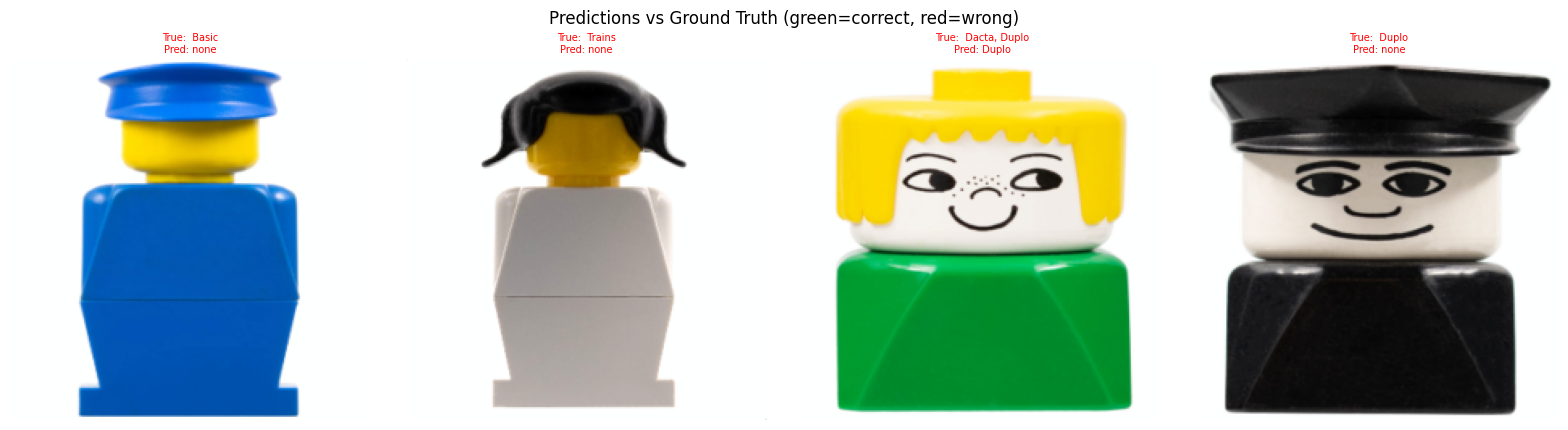

In [24]:
# ── Visualize predictions vs ground truth ─────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Limit the loop to the actual number of images in the batch
for i in range(images.shape[0]):
    ax = axes.flat[i]
    # Undo normalization for display
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)
    ax.imshow(img)

    # Ground truth themes
    true_themes = [selected_themes[j] for j in range(TOP_K) if labels_batch[i][j] == 1]
    # Predicted themes
    pred_themes = [selected_themes[j] for j in range(TOP_K) if preds[i][j] == 1]

    # Color title green if perfect match, red if not
    correct = set(true_themes) == set(pred_themes)
    color = "green" if correct else "red"

    ax.set_title(
        f"True:  {', '.join(true_themes)}\nPred: {', '.join(pred_themes) if pred_themes else 'none'}",
        fontsize=7,
        color=color
    )
    ax.axis("off")

# Hide any unused subplots
for i in range(images.shape[0], len(axes.flat)):
    axes.flat[i].set_visible(False)

plt.suptitle("Predictions vs Ground Truth (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
# ── Get predictions on the full val set ───────────────────────
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        outputs = outputs.view(outputs.size(0), -1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Probabilities shape:", all_probs.shape)   

Probabilities shape: (2374, 55)


## Improve model by trying different thresholds

In [26]:
from sklearn.metrics import f1_score

# ── Try different thresholds and pick the best ─────────────────
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    preds = (all_probs > t).astype(int)
    f1 = f1_score(all_labels, preds, average="macro", zero_division=0)
    marker = " <-- best" if f1 > best_f1 else ""
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
    print(f"Threshold {t} | Val F1: {f1:.4f}{marker}")

print(f"\nBest threshold: {best_threshold} | Best Val F1: {best_f1:.4f}")

Threshold 0.2 | Val F1: 0.4366 <-- best
Threshold 0.25 | Val F1: 0.4156
Threshold 0.3 | Val F1: 0.4160
Threshold 0.35 | Val F1: 0.4000
Threshold 0.4 | Val F1: 0.3953
Threshold 0.45 | Val F1: 0.3790
Threshold 0.5 | Val F1: 0.3630

Best threshold: 0.2 | Best Val F1: 0.4366


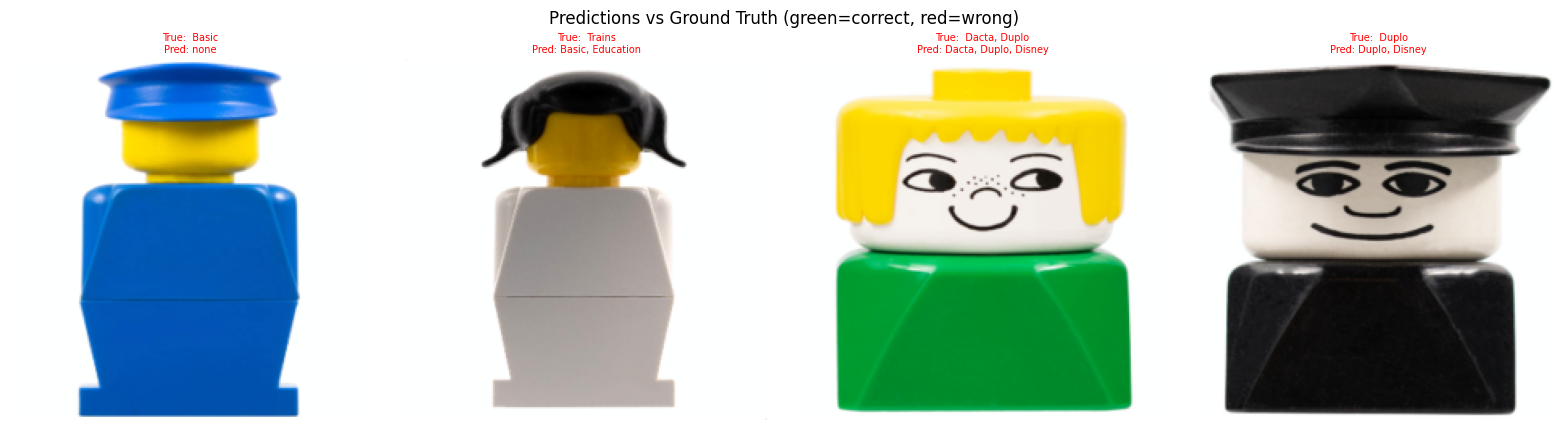

In [27]:
# ── Visualize predictions vs ground truth with best threshold ──
images_v, labels_v = next(iter(val_loader))
images_v = images_v.to(device)

with torch.no_grad():
    outputs = model(images_v)
    outputs = outputs.view(outputs.size(0), -1)
    probs = torch.sigmoid(outputs).cpu().numpy()
    preds = (probs > best_threshold).astype(int)  # using 0.2 now

labels_v = labels_v.numpy()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Limit the loop to the actual number of images in the batch
for i in range(images_v.shape[0]):
    ax = axes.flat[i]
    # Undo normalization for display
    img = images_v[i].cpu().permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)
    ax.imshow(img)

    # Ground truth themes
    true_themes = [selected_themes[j] for j in range(TOP_K) if labels_v[i][j] == 1]
    # Predicted themes
    pred_themes = [selected_themes[j] for j in range(TOP_K) if preds[i][j] == 1]

    # Color title green if perfect match, red if not
    correct = set(true_themes) == set(pred_themes)
    color = "green" if correct else "red"

    ax.set_title(
        f"True:  {', '.join(true_themes)}\nPred: {', '.join(pred_themes) if pred_themes else 'none'}",
        fontsize=7,
        color=color
    )
    ax.axis("off")

# Hide any unused subplots
for i in range(images_v.shape[0], len(axes.flat)):
    axes.flat[i].set_visible(False)

plt.suptitle("Predictions vs Ground Truth (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.show()

## Interpretability

In [28]:
# ── Install pytorch_grad_cam if not already installed ────────
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── SqueezeNet: last conv layer is features[12] ────────────────
target_layers = [model.features[12]]
cam = GradCAM(model=model, target_layers=target_layers)

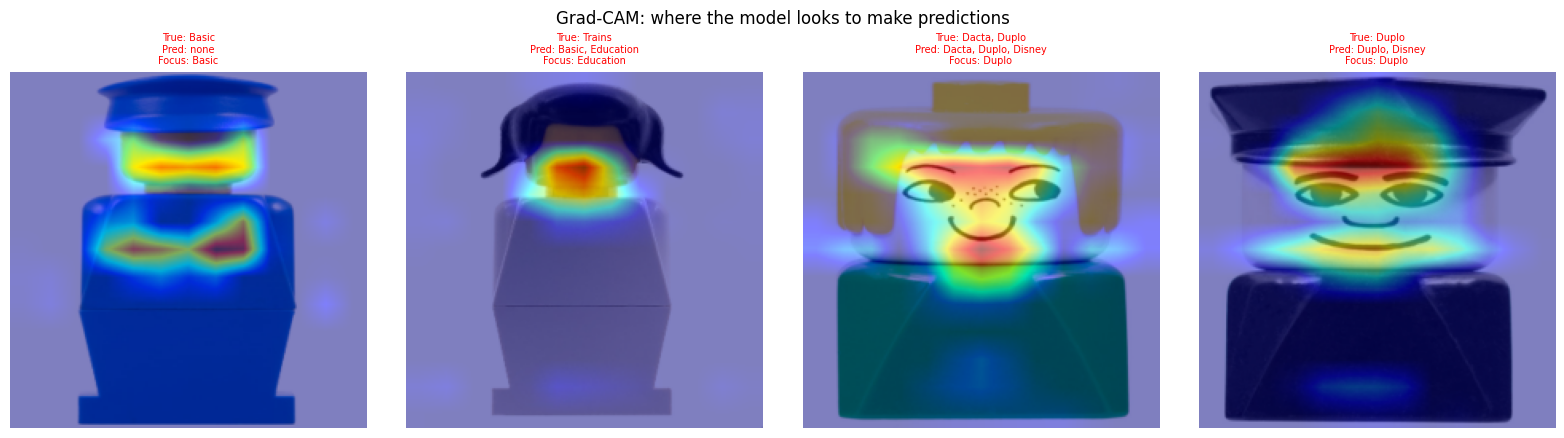

In [29]:
# ── Get a fresh batch from val set ────────────────────────────
images_batch, labels_batch = next(iter(val_loader))
images_batch = images_batch.to(device)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(images_batch.shape[0]): # Loop only for the number of images in the batch
    ax = axes.flat[i]
    img_tensor = images_batch[i].unsqueeze(0)

    # Get predicted themes for this image
    with torch.no_grad():
        output = model(img_tensor)
        output = output.view(1, -1)
        probs  = torch.sigmoid(output).cpu().numpy()[0]

    pred_indices = np.where(probs > best_threshold)[0]

    # Use the most confident prediction for Grad-CAM
    if len(pred_indices) > 0:
        target_class = pred_indices[probs[pred_indices].argmax()]
    else:
        target_class = probs.argmax()

    targets = [ClassifierOutputTarget(int(target_class))]

    # Generate heatmap
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

    # Undo normalization for display
    img_np = images_batch[i].cpu().permute(1, 2, 0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = img_np.clip(0, 1).astype(np.float32)

    # Overlay heatmap on image
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    ax.imshow(visualization)

    true_themes = [selected_themes[j] for j in range(TOP_K) if labels_batch[i][j] == 1]
    pred_themes = [selected_themes[j] for j in range(TOP_K) if probs[j] > best_threshold]
    correct = set(true_themes) == set(pred_themes)

    # Show which theme the heatmap is for
    focus_theme = selected_themes[target_class]
    ax.set_title(
        f"True: {', '.join(true_themes)}\nPred: {', '.join(pred_themes) if pred_themes else 'none'}\nFocus: {focus_theme}",
        fontsize=7,
        color="green" if correct else "red"
    )
    ax.axis("off")

# Hide any unused subplots
for i in range(images_batch.shape[0], len(axes.flat)): # Start hiding from the first unused subplot
    axes.flat[i].set_visible(False)

plt.suptitle("Grad-CAM: where the model looks to make predictions", fontsize=12)
plt.tight_layout()
plt.show()

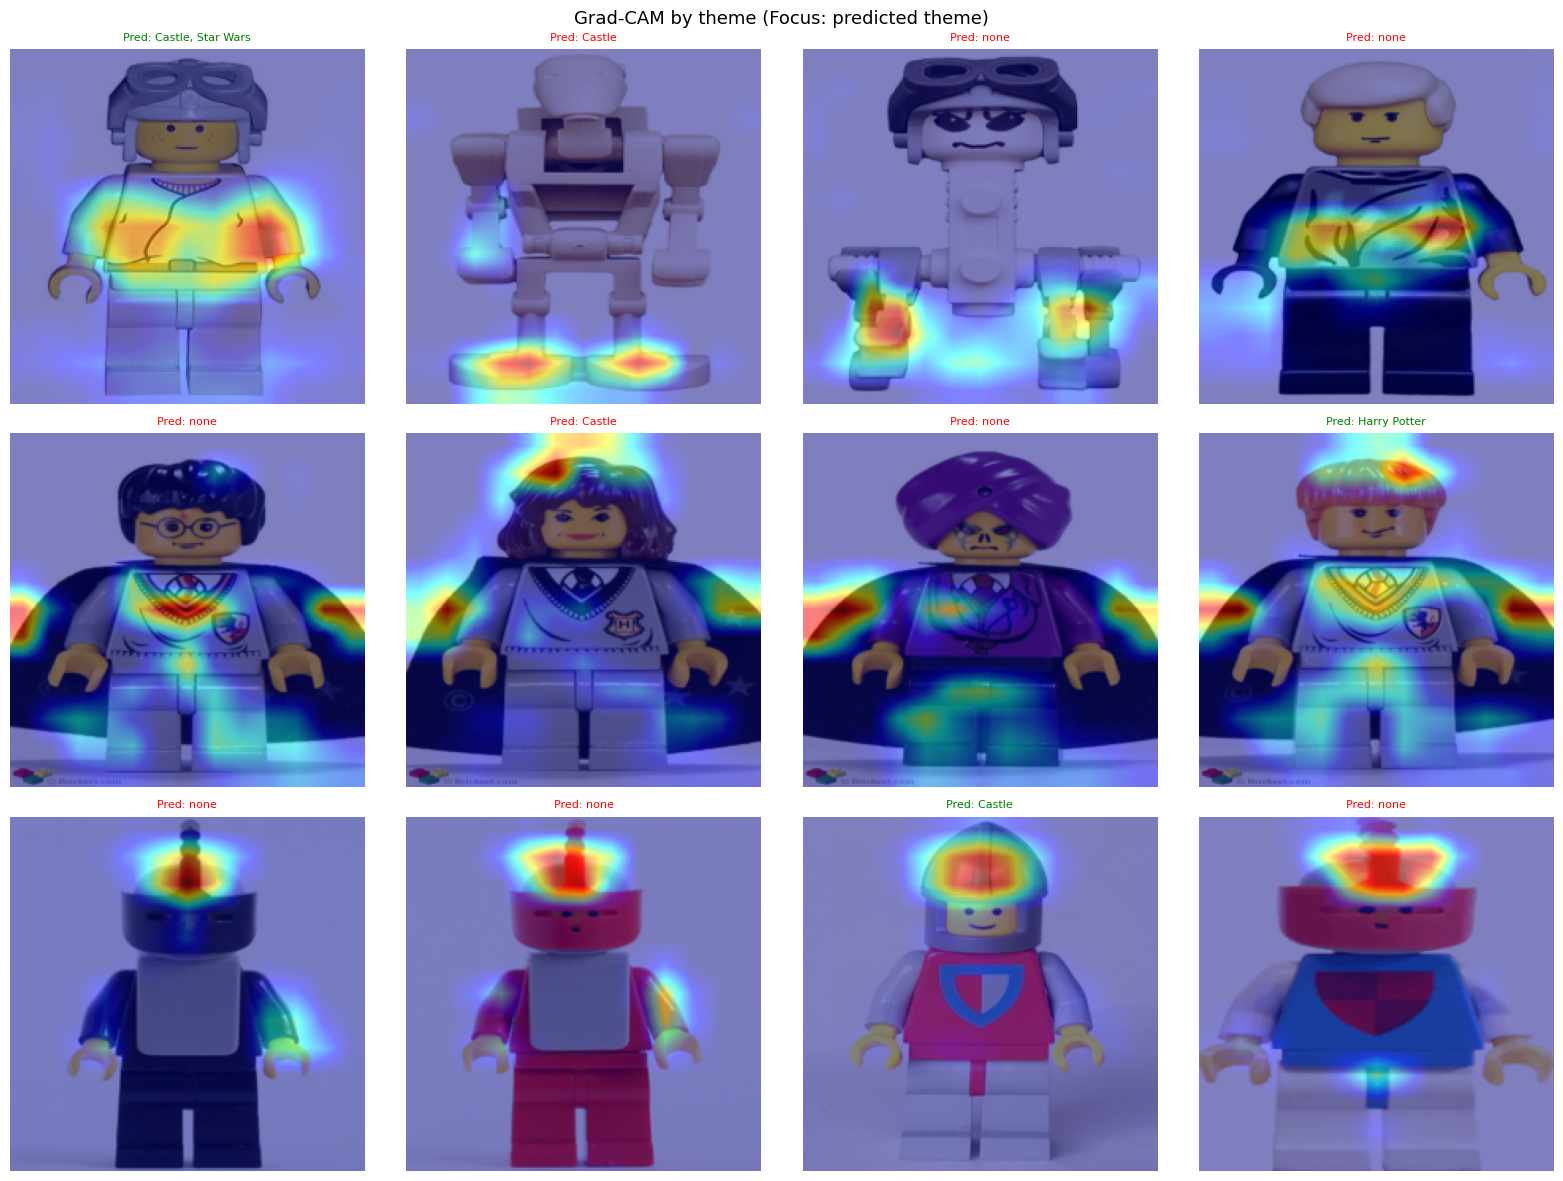

In [34]:
# ── Grad-CAM filtered by specific themes ──────────────────────
themes_to_show = ["Star Wars", "Harry Potter", "Castle"]
images_per_theme = 4

fig, axes = plt.subplots(len(themes_to_show), images_per_theme, figsize=(16, 12))

for row, theme in enumerate(themes_to_show):
    theme_idx = selected_themes.index(theme)
    collected = 0

    # Loop through val set to find images of this theme
    for images_batch, labels_batch in val_loader:
        if collected >= images_per_theme:
            break

        for i in range(len(images_batch)):
            if collected >= images_per_theme:
                break

            # Only use images that truly belong to this theme
            if labels_batch[i][theme_idx] != 1:
                continue

            img_tensor = images_batch[i].unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(img_tensor)
                output = output.view(1, -1)
                probs  = torch.sigmoid(output).cpu().numpy()[0]

            # Grad-CAM focused on this specific theme
            targets = [ClassifierOutputTarget(theme_idx)]
            grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

            # Undo normalization
            img_np = images_batch[i].permute(1, 2, 0).numpy()
            img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
            img_np = img_np.clip(0, 1).astype(np.float32)

            visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            ax = axes[row, collected]
            ax.imshow(visualization)

            pred_themes = [selected_themes[j] for j in range(TOP_K) if probs[j] > best_threshold]
            correct = theme in pred_themes
            ax.set_title(
                f"Pred: {', '.join(pred_themes) if pred_themes else 'none'}",
                fontsize=8,
                color="green" if correct else "red"
            )
            ax.axis("off")
            collected += 1

    # Add theme label on the left
    axes[row, 0].set_ylabel(theme, fontsize=12, fontweight="bold", rotation=90, labelpad=10)

plt.suptitle("Grad-CAM by theme (Focus: predicted theme)", fontsize=13)
plt.tight_layout()
plt.show()

### Upload best model

In [35]:
import os
import gc
import torch
import numpy as np
from sklearn.metrics import f1_score
# ── 1. Load the surviving model ───────────────────────────────
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    print("📦 Model weights loaded successfully from disk.")
else:
    print("⚠️ 'best_model.pth' not found. Starting with current memory weights.")

model = model.to(device)

# ── 2. Re-calculate current baseline ──────────────────────────
# We do this to ensure best_val_f1 is updated even after a kernel crash
model.eval()
all_probs = []
val_labels_list = []

print("Running baseline evaluation to resume metrics...")
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        out = model(imgs).view(imgs.size(0), -1)
        all_probs.append(torch.sigmoid(out).cpu().numpy())
        val_labels_list.append(labels.numpy())

all_probs = np.concatenate(all_probs)
val_labels = np.concatenate(val_labels_list)
# Use your optimized threshold of 0.2
current_f1 = f1_score(val_labels, (all_probs > 0.2).astype(int), average="macro", zero_division=0)

best_val_f1 = current_f1
best_threshold = 0.2
print(f"✅ Resumed with Best F1: {best_val_f1:.4f}")

📦 Model weights loaded successfully from disk.
Running baseline evaluation to resume metrics...
✅ Resumed with Best F1: 0.4366


In [36]:
# ── Load and Get Probs from Best Model ────────────────────────
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

all_probs = []
all_labels = []

print("Extracting probabilities from the best model...")
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        # Forward pass
        out = model(imgs).view(imgs.size(0), -1)
        # Apply sigmoid to get [0, 1] range
        all_probs.append(torch.sigmoid(out).cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
print("Done! Probabilities are ready.")

Extracting probabilities from the best model...
Done! Probabilities are ready.


In [37]:
from sklearn.metrics import f1_score

# ── Try different thresholds and pick the best ─────────────────
# I added 0.1 and 0.15 since SqueezeNet often benefits from lower thresholds
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

best_f1_val = 0
best_t = 0.5

print(f"Searching best threshold for {best_val_f1:.4f} baseline...\n")

for t in thresholds:
    # Convert probabilities to binary predictions
    preds = (all_probs > t).astype(int)
    f1 = f1_score(all_labels, preds, average="macro", zero_division=0)
    
    if f1 > best_f1_val:
        best_f1_val = f1
        best_t = t
        marker = " <-- NEW BEST"
    else:
        marker = ""
        
    print(f"Threshold {t:.2f} | Val F1: {f1:.4f}{marker}")

# Update your global best_threshold variable for the rest of the notebook
best_threshold = best_t
print(f"\nFinal Result -> Best threshold: {best_threshold} | Best Val F1: {best_f1_val:.4f}")

Searching best threshold for 0.4366 baseline...

Threshold 0.10 | Val F1: 0.4114 <-- NEW BEST
Threshold 0.15 | Val F1: 0.4232 <-- NEW BEST
Threshold 0.20 | Val F1: 0.4366 <-- NEW BEST
Threshold 0.25 | Val F1: 0.4156
Threshold 0.30 | Val F1: 0.4160
Threshold 0.35 | Val F1: 0.4000
Threshold 0.40 | Val F1: 0.3953
Threshold 0.45 | Val F1: 0.3790
Threshold 0.50 | Val F1: 0.3630

Final Result -> Best threshold: 0.2 | Best Val F1: 0.4366


### Final Test

In [38]:
import torch
import numpy as np
import gc
from sklearn.metrics import classification_report, f1_score

# ── 1. Preparation ─────────────────────────────────────────────
# Clear memory before starting
gc.collect()
torch.cuda.empty_cache()

# Load the best weights saved during training
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

all_test_probs = []
all_test_labels = []

print("🚀 Starting inference on Test Set...")

# ── 2. Inference Loop ──────────────────────────────────────────
with torch.no_grad():
    for imgs, labels in test_loader: # Ensure test_loader is defined
        imgs = imgs.to(device)
        
        # Get model output
        out = model(imgs).view(imgs.size(0), -1)
        
        # Convert to probabilities [0, 1]
        probs = torch.sigmoid(out).cpu().numpy()
        
        all_test_probs.append(probs)
        all_test_labels.append(labels.numpy())

# Combine all batches
all_test_probs = np.concatenate(all_test_probs)
all_test_labels = np.concatenate(all_test_labels)

# ── 3. Apply the Optimal Threshold (0.2) ───────────────────────
test_preds = (all_test_probs > best_threshold).astype(int)

# ── 4. Final Results ───────────────────────────────────────────
test_f1 = f1_score(all_test_labels, test_preds, average="macro", zero_division=0)

print("-" * 30)
print(f"TEST SET RESULTS")
print(f"Final Test F1-Score (Macro): {test_f1:.4f}")
print("-" * 30)

# Detailed report per theme
print("\nDetailed Test Classification Report:")
print(classification_report(all_test_labels, test_preds, zero_division=0))

🚀 Starting inference on Test Set...
------------------------------
TEST SET RESULTS
Final Test F1-Score (Macro): 0.3996
------------------------------

Detailed Test Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.33      0.26         9
           1       0.33      0.16      0.21        19
           2       0.17      0.53      0.26        38
           3       0.81      0.78      0.80       125
           4       0.64      0.91      0.75        69
           5       0.50      0.12      0.19        26
           6       0.40      0.83      0.54       105
           7       1.00      0.92      0.96        13
           8       0.57      0.60      0.58        35
           9       0.00      0.00      0.00        30
          10       0.23      0.21      0.22        68
          11       0.78      0.82      0.80        22
          12       0.68      0.88      0.77        17
          13       0.20      0.38      0.26         8
